<a href="https://colab.research.google.com/github/seliyeva1810/walmart-machine-learning-project/blob/main/Final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!curl -L -o walmart-sales-forecast.zip https://www.kaggle.com/api/v1/datasets/download/aslanahmedov/walmart-sales-forecast

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 3441k  100 3441k    0     0  6913k      0 --:--:-- --:--:-- --:--:-- 6913k


In [ ]:
!unzip walmart-sales-forecast.zip

Archive:  walmart-sales-forecast.zip
  inflating: features.csv            
  inflating: stores.csv              
  inflating: test.csv                
  inflating: train.csv               


In [ ]:
import pandas as pd

In [ ]:
f_df=pd.read_csv('/content/features.csv')
s_df=pd.read_csv('/content/stores.csv')
test_df=pd.read_csv('/content/test.csv')
train_df=pd.read_csv('/content/train.csv')

In [ ]:
f_df

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8185,45,2013-06-28,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False
8186,45,2013-07-05,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False
8187,45,2013-07-12,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False
8188,45,2013-07-19,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False


In [ ]:
s_df

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875
5,6,A,202505
6,7,B,70713
7,8,A,155078
8,9,B,125833
9,10,B,126512


In [ ]:
test_df

,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False
...,...,...,...,...
115059,45,98,2013-06-28,False
115060,45,98,2013-07-05,False
115061,45,98,2013-07-12,False
115062,45,98,2013-07-19,False


In [ ]:
train_df

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False
...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False
421566,45,98,2012-10-05,628.10,False
421567,45,98,2012-10-12,1061.02,False
421568,45,98,2012-10-19,760.01,False


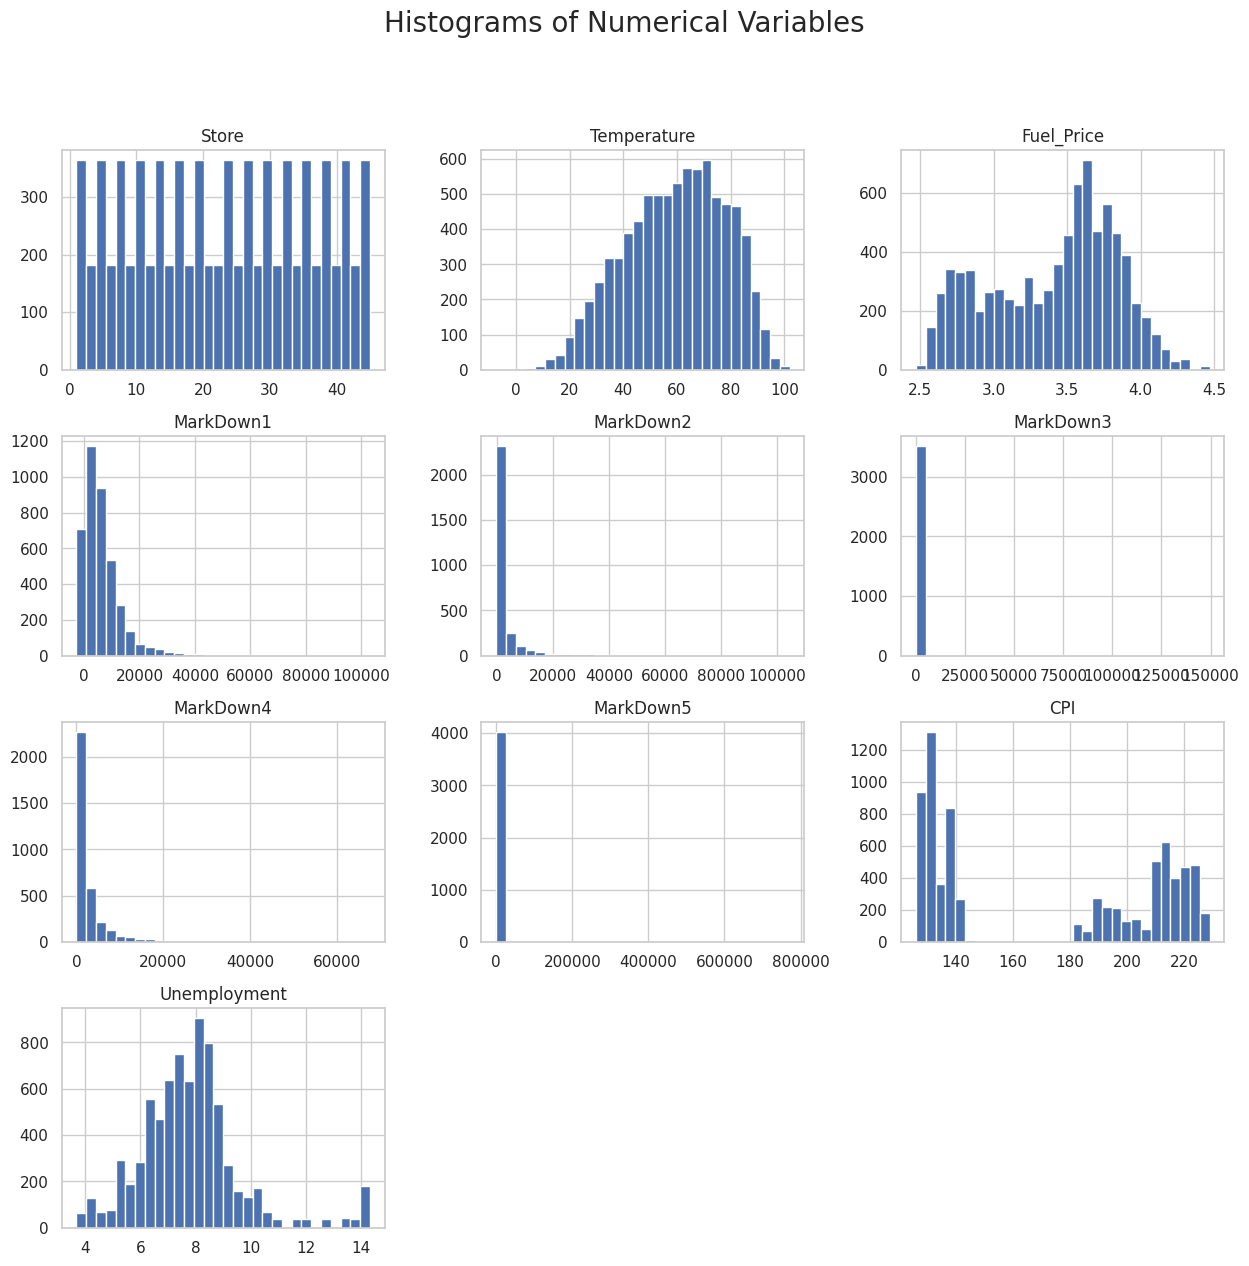

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
f_df.hist(bins=30, figsize=(15, 14))
plt.suptitle('Histograms of Numerical Variables', fontsize=20)
plt.show()

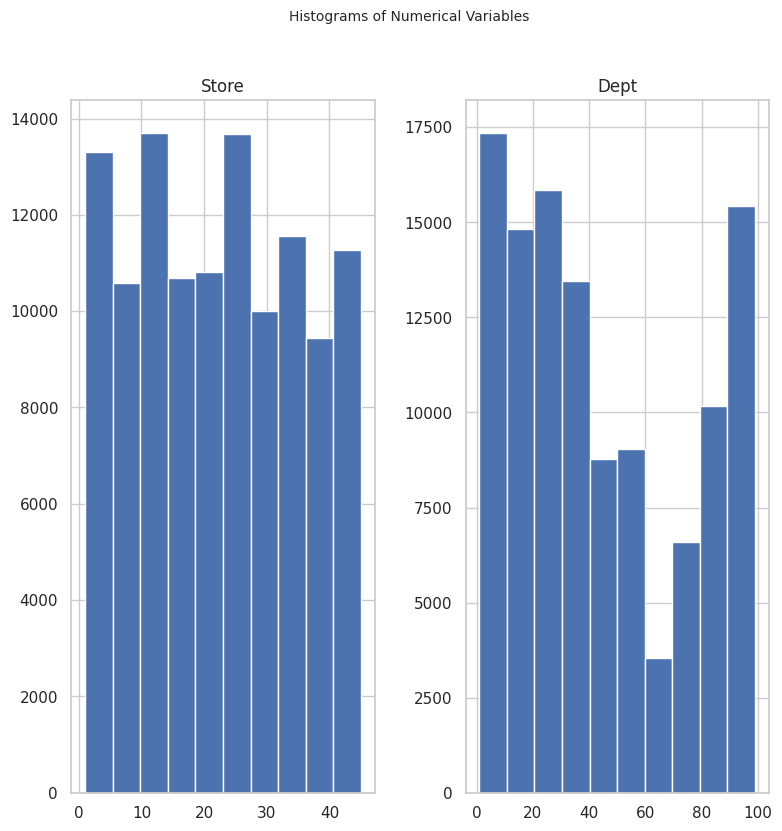

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
test_df.hist(bins=10, figsize=(9, 9))
plt.suptitle('Histograms of Numerical Variables', fontsize=10)
plt.show()

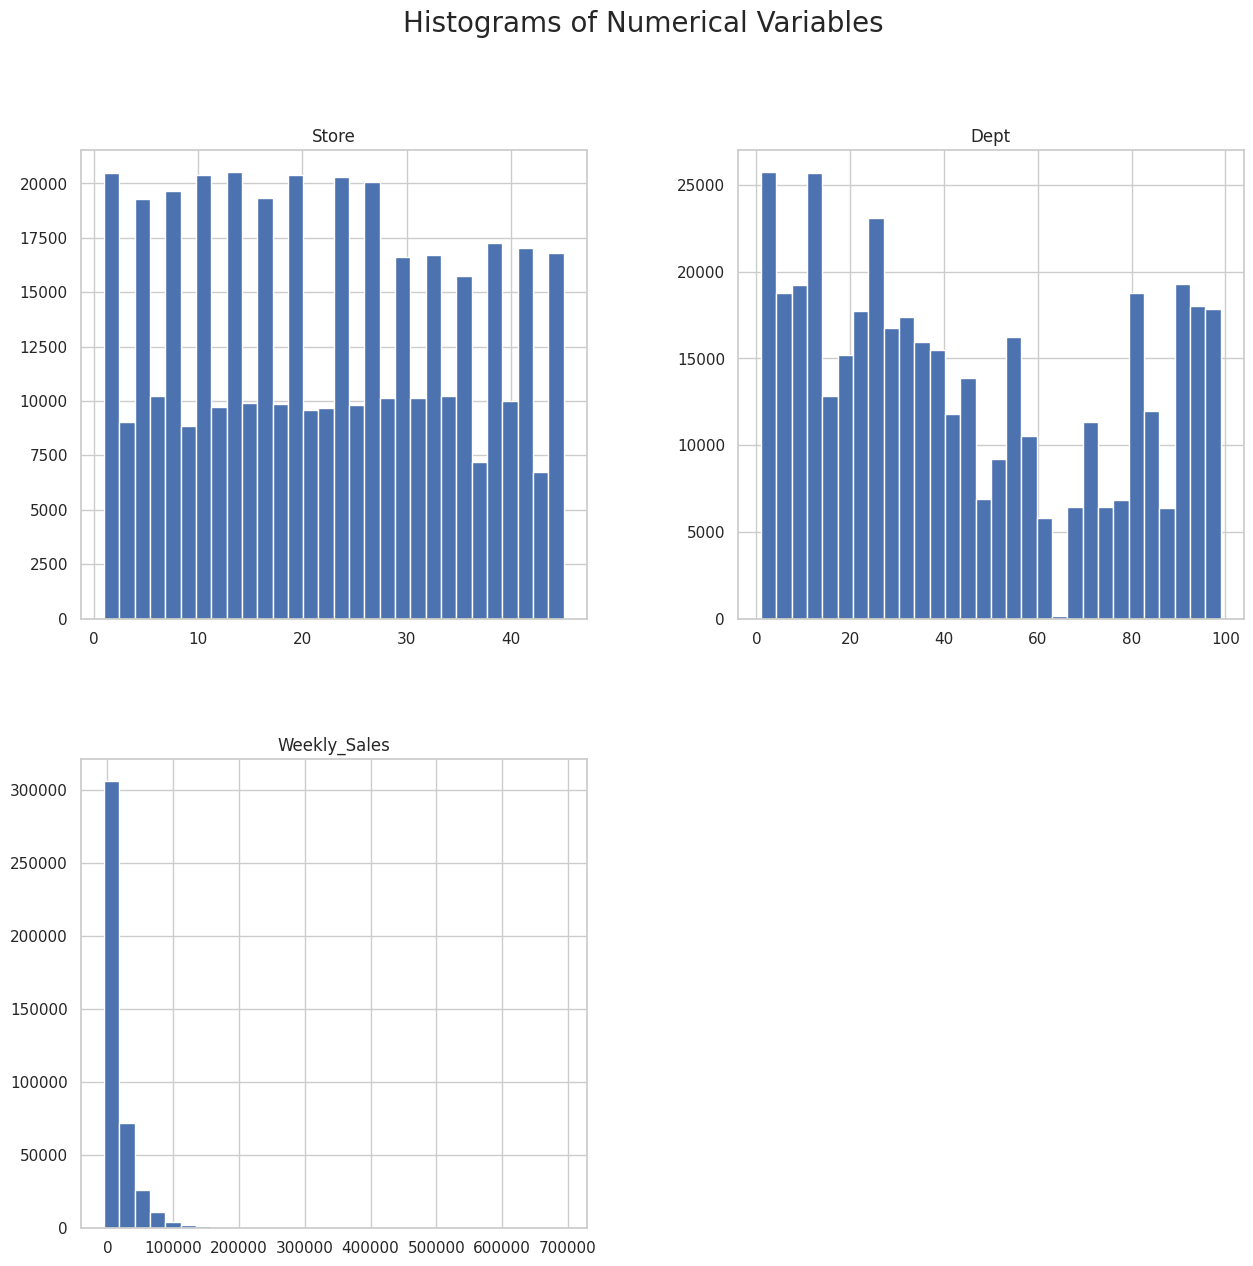

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
train_df.hist(bins=30, figsize=(15, 14))
plt.suptitle('Histograms of Numerical Variables', fontsize=20)
plt.show()

<Axes: >

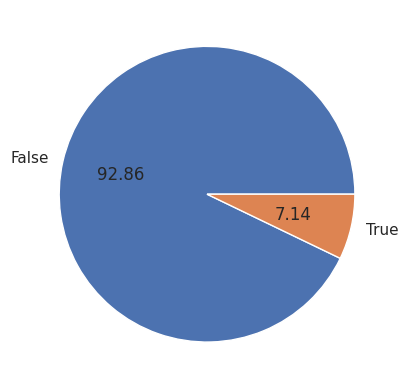

In [ ]:
f_df.groupby('IsHoliday').size().plot(kind='pie', autopct='%.2f')

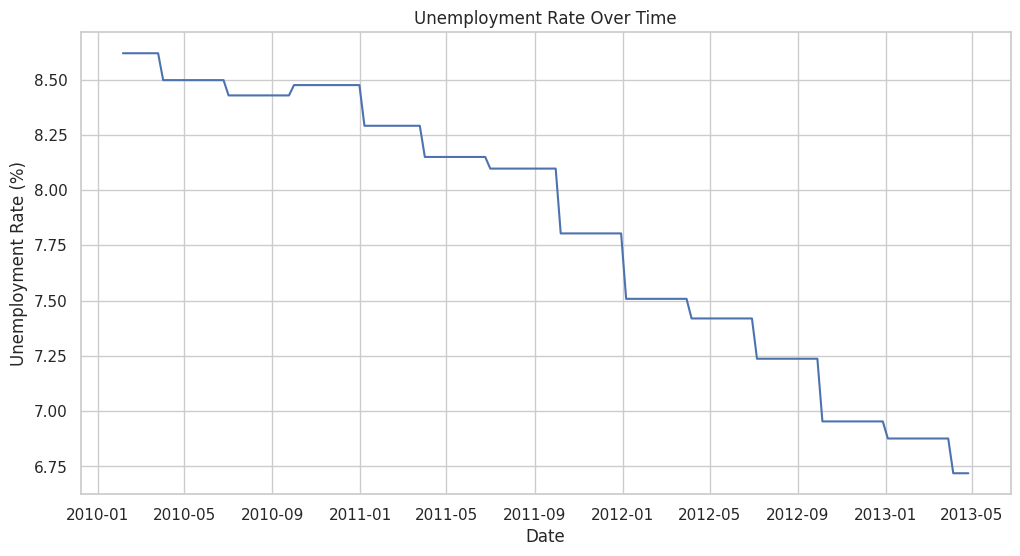

In [ ]:
#zaman üzrə işsizlik səviyyəsinin(Unemployment) dəyişməsini göstərən xətti qrafik
f_df['Date'] = pd.to_datetime(f_df['Date']) #Date sütununu datetime formatına çevirir ki, zaman üzrə analiz edə bilək
df_grouped = f_df.groupby('Date')['Unemployment'].mean().reset_index() #nəticəni DataFrame şəklinə salır

plt.figure(figsize=(12, 6))
plt.plot(df_grouped['Date'], df_grouped['Unemployment'])
plt.title('Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')

plt.grid(True)
plt.show()

In [ ]:
tt_df=pd.concat([train_df,test_df])

In [ ]:
df=pd.concat([tt_df,f_df,s_df])

In [ ]:
df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1.0,2010-02-05,24924.50,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1.0,2010-02-12,46039.49,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1.0,2010-02-19,41595.55,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,1.0,2010-02-26,19403.54,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,1.0,2010-03-05,21827.90,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,196321.0
41,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C,39690.0
42,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C,41062.0
43,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C,39910.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 544869 entries, 0 to 44
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         544869 non-null  int64  
 1   Dept          536634 non-null  float64
 2   Date          544824 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     544824 non-null  object 
 5   Temperature   8190 non-null    float64
 6   Fuel_Price    8190 non-null    float64
 7   MarkDown1     4032 non-null    float64
 8   MarkDown2     2921 non-null    float64
 9   MarkDown3     3613 non-null    float64
 10  MarkDown4     3464 non-null    float64
 11  MarkDown5     4050 non-null    float64
 12  CPI           7605 non-null    float64
 13  Unemployment  7605 non-null    float64
 14  Type          45 non-null      object 
 15  Size          45 non-null      float64
dtypes: float64(12), int64(1), object(3)
memory usage: 70.7+ MB


In [ ]:
df.dtypes

,0
Store,int64
Dept,float64
Date,object
Weekly_Sales,float64
IsHoliday,object
Temperature,float64
Fuel_Price,float64
MarkDown1,float64
MarkDown2,float64
MarkDown3,float64


In [ ]:
df.isnull().sum()

,0
Store,0
Dept,8235
Date,45
Weekly_Sales,123299
IsHoliday,45
Temperature,536679
Fuel_Price,536679
MarkDown1,540837
MarkDown2,541948
MarkDown3,541256


In [ ]:
df.drop_duplicates()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1.0,2010-02-05,24924.50,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1.0,2010-02-12,46039.49,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1.0,2010-02-19,41595.55,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,1.0,2010-02-26,19403.54,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,1.0,2010-03-05,21827.90,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,196321.0
41,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C,39690.0
42,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C,41062.0
43,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C,39910.0


In [ ]:
numeric_columns=df.select_dtypes(include=['number']).columns
df[numeric_columns]=df[numeric_columns].fillna(df[numeric_columns].mean())

In [ ]:
text_columns=df.select_dtypes(include=['object']).columns
# df[text_columns]=df[text_columns].fillna(df[text_columns].mode().iloc[0]) belede yazmaq olar
for col in text_columns:
  df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'bilinmir')

/tmp/ipykernel_13634/1661827725.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'bilinmir')


In [ ]:
df.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,0
MarkDown2,0
MarkDown3,0


In [ ]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1.0,2010-02-05,24924.50,False,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,A,130287.6
1,1,1.0,2010-02-12,46039.49,True,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,A,130287.6
2,1,1.0,2010-02-19,41595.55,False,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,A,130287.6
3,1,1.0,2010-02-26,19403.54,False,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,A,130287.6
4,1,1.0,2010-03-05,21827.90,False,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,A,130287.6


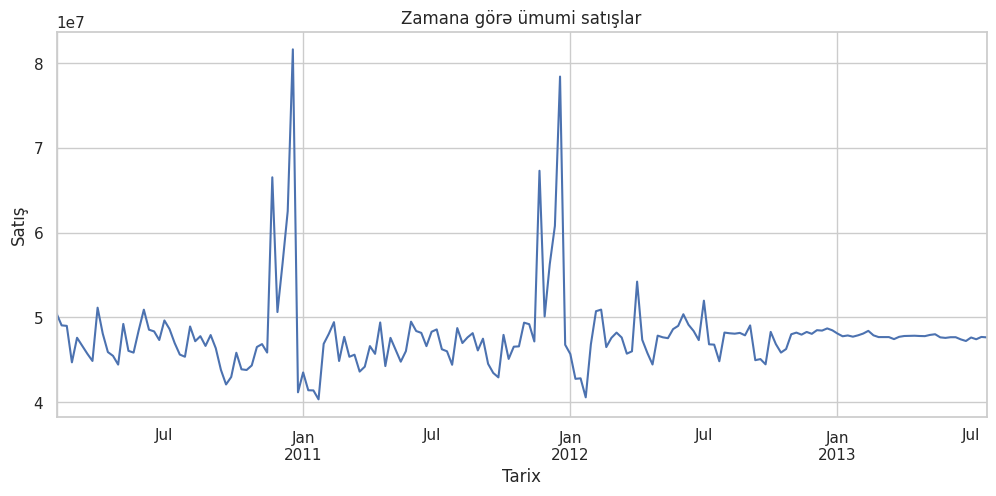

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
sales_by_date = df.groupby('Date')['Weekly_Sales'].sum()

sales_by_date.plot(figsize=(12,5))
plt.title('Zamana görə ümumi satışlar')
plt.ylabel('Satış')
plt.xlabel('Tarix')
plt.show()

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['Weekday'] = df['Date'].dt.weekday
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

df = df.drop(columns=['Date'])

In [ ]:
df

,Store,Dept,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Weekday,Month,Year
0,1,1.000000,24924.500000,False,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,A,130287.6,4,2,2010
1,1,1.000000,46039.490000,True,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,A,130287.6,4,2,2010
2,1,1.000000,41595.550000,False,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,A,130287.6,4,2,2010
3,1,1.000000,19403.540000,False,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,A,130287.6,4,2,2010
4,1,1.000000,21827.900000,False,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,A,130287.6,4,3,2010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40,41,44.277301,15981.258123,False,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,A,196321.0,4,12,2011
41,42,44.277301,15981.258123,False,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,C,39690.0,4,12,2011
42,43,44.277301,15981.258123,False,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,C,41062.0,4,12,2011
43,44,44.277301,15981.258123,False,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,C,39910.0,4,12,2011


In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()
encoded = encoder.fit_transform(df[['Type']]).toarray()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])
df['IsHoliday'] = le.fit_transform(df['IsHoliday'])

In [ ]:
df.dtypes

,0
Store,int64
Dept,float64
Weekly_Sales,float64
IsHoliday,int64
Temperature,float64
Fuel_Price,float64
MarkDown1,float64
MarkDown2,float64
MarkDown3,float64
MarkDown4,float64


In [ ]:
df

,Store,Dept,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Weekday,Month,Year
0,1,1.000000,24924.500000,0,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,0,130287.6,4,2,2010
1,1,1.000000,46039.490000,1,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,0,130287.6,4,2,2010
2,1,1.000000,41595.550000,0,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,0,130287.6,4,2,2010
3,1,1.000000,19403.540000,0,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,0,130287.6,4,2,2010
4,1,1.000000,21827.900000,0,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,0,130287.6,4,3,2010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40,41,44.277301,15981.258123,0,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,0,196321.0,4,12,2011
41,42,44.277301,15981.258123,0,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,2,39690.0,4,12,2011
42,43,44.277301,15981.258123,0,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,2,41062.0,4,12,2011
43,44,44.277301,15981.258123,0,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,2,39910.0,4,12,2011


In [ ]:
print(df.columns) #DataFrame sütun adlarını yoxla

Index(['Store', 'Dept', 'Weekly_Sales', 'IsHoliday', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size', 'Weekday', 'Month',
       'Year'],
      dtype='object')


In [ ]:
# Median əsasında yüksək/aşağı satış:
df['High_Sales'] = (df['Weekly_Sales'] > df['Weekly_Sales'].median()).astype(int)

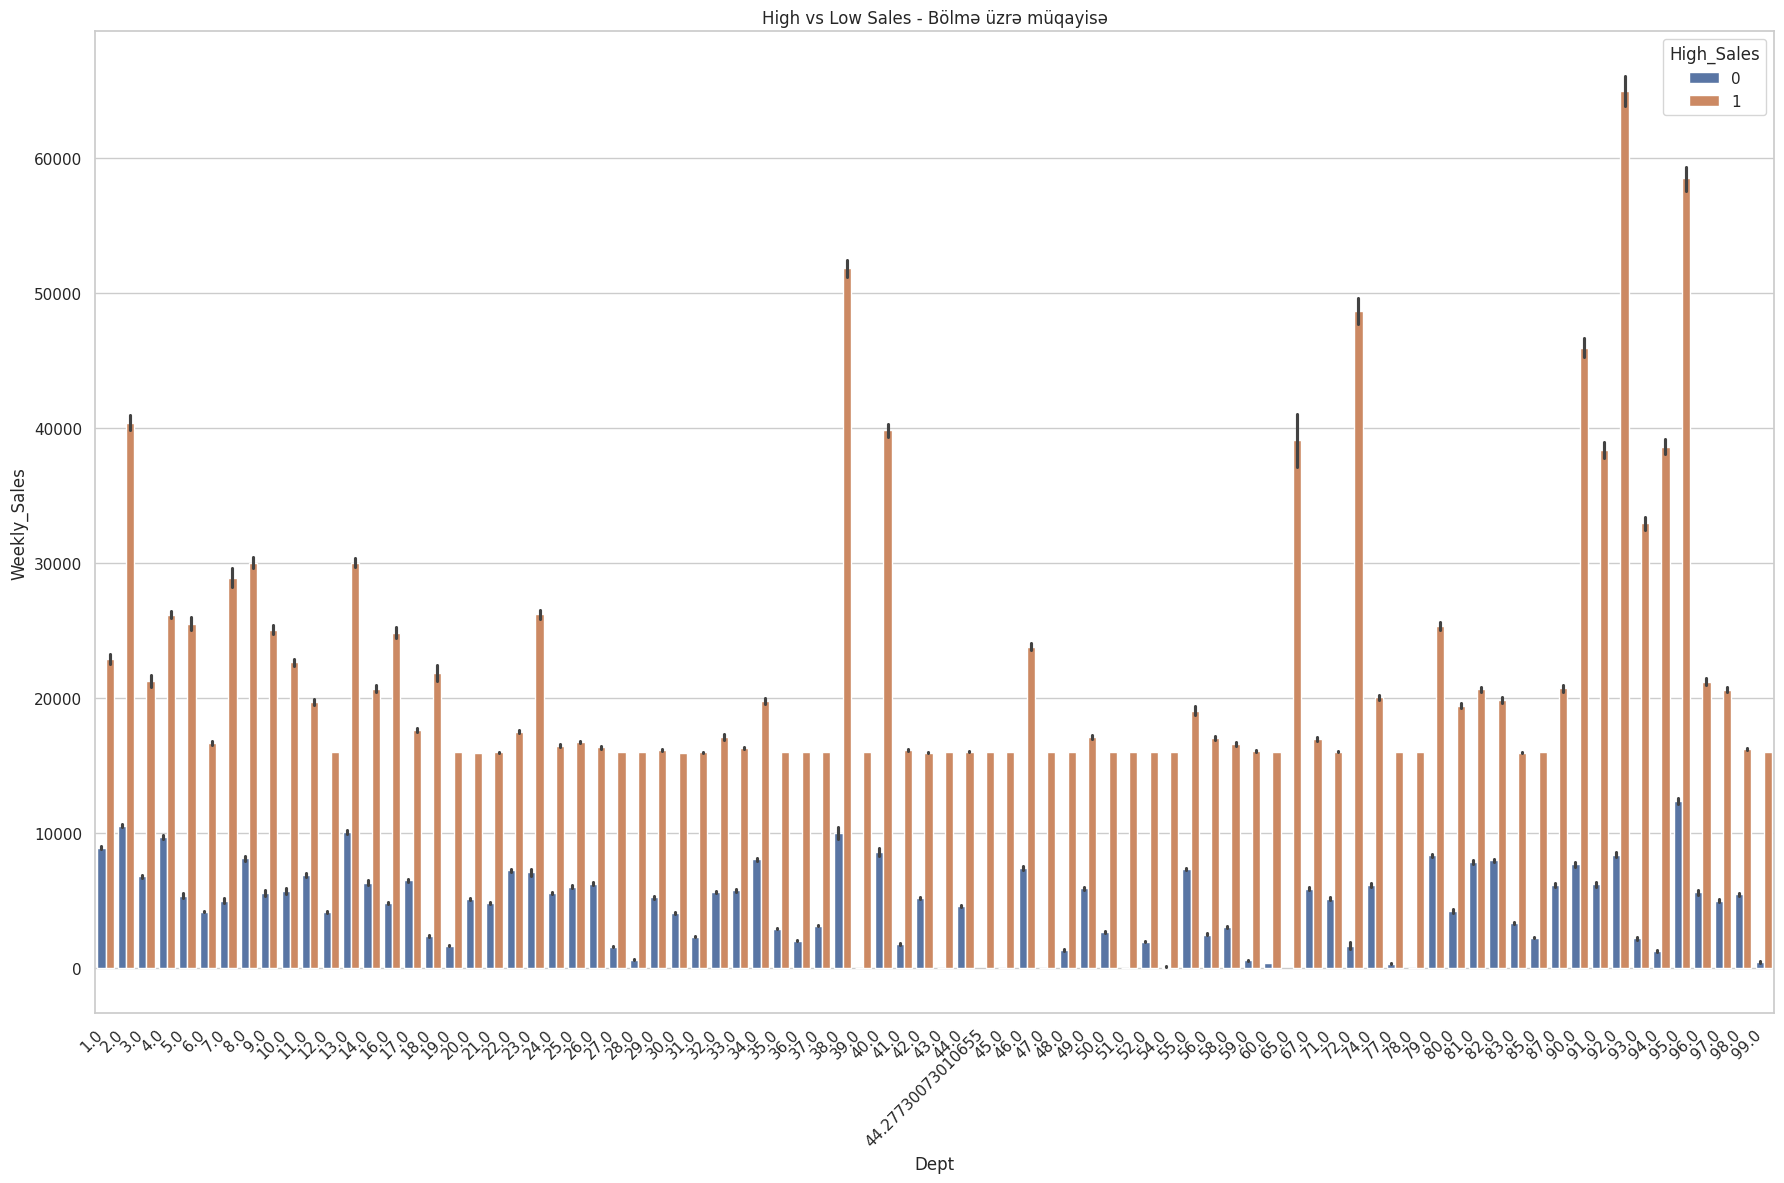

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 12))
sns.barplot(x='Dept', y='Weekly_Sales', hue='High_Sales', data=df)
plt.xticks(rotation=45, ha='right')  # Yazıları sağa meylləndir
plt.title("High vs Low Sales - Bölmə üzrə müqayisə")
plt.tight_layout()  # Avtomatik boşluqları düzəldir
plt.show()



In [ ]:
#Outlierlərin təmizlənməsi
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

df_clean = remove_outliers(df, 'Weekly_Sales')


In [ ]:
X = df.drop(columns=['Weekly_Sales', 'High_Sales'])
y = df['High_Sales']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X.shape,X_train.shape,X_test.shape,y_train.shape,y_test.shape

((544869, 17), (435895, 17), (108974, 17), (435895,), (108974,))

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import SGDClassifier
sgd_clf=SGDClassifier(random_state=42)
sgd_clf.fit(X_train,y_train)

SGDClassifier(random_state=42)

In [ ]:
sgd_clf.score(X_train,y_train)

0.6471214397962812

In [ ]:
sgd_clf.score(X_test,y_test)

0.6494760218033659

In [ ]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf,X_train,y_train,cv=3,scoring='accuracy')

array([0.64825635, 0.64812317, 0.6524522 ])

In [ ]:
from sklearn.model_selection import cross_val_predict
y_train_pred=cross_val_predict(sgd_clf,X_train,y_train,cv=3)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
model.score(X_train,y_train)

0.9858062147994356

In [ ]:
model.score(X_test,y_test)

0.968542955200323

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(eval_metric='logloss')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
model.score(X_train,y_train)

0.964369859713922

In [ ]:
model.score(X_test,y_test)

0.9643492943270872

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [ ]:
lr.score(X_train,y_train)

0.6420674703770404

In [ ]:
lr.score(X_test,y_test)

0.6443371813460091

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
model.score(X_train,y_train)

0.7857259202330836

In [ ]:
model.score(X_test,y_test)

0.7866004735074421

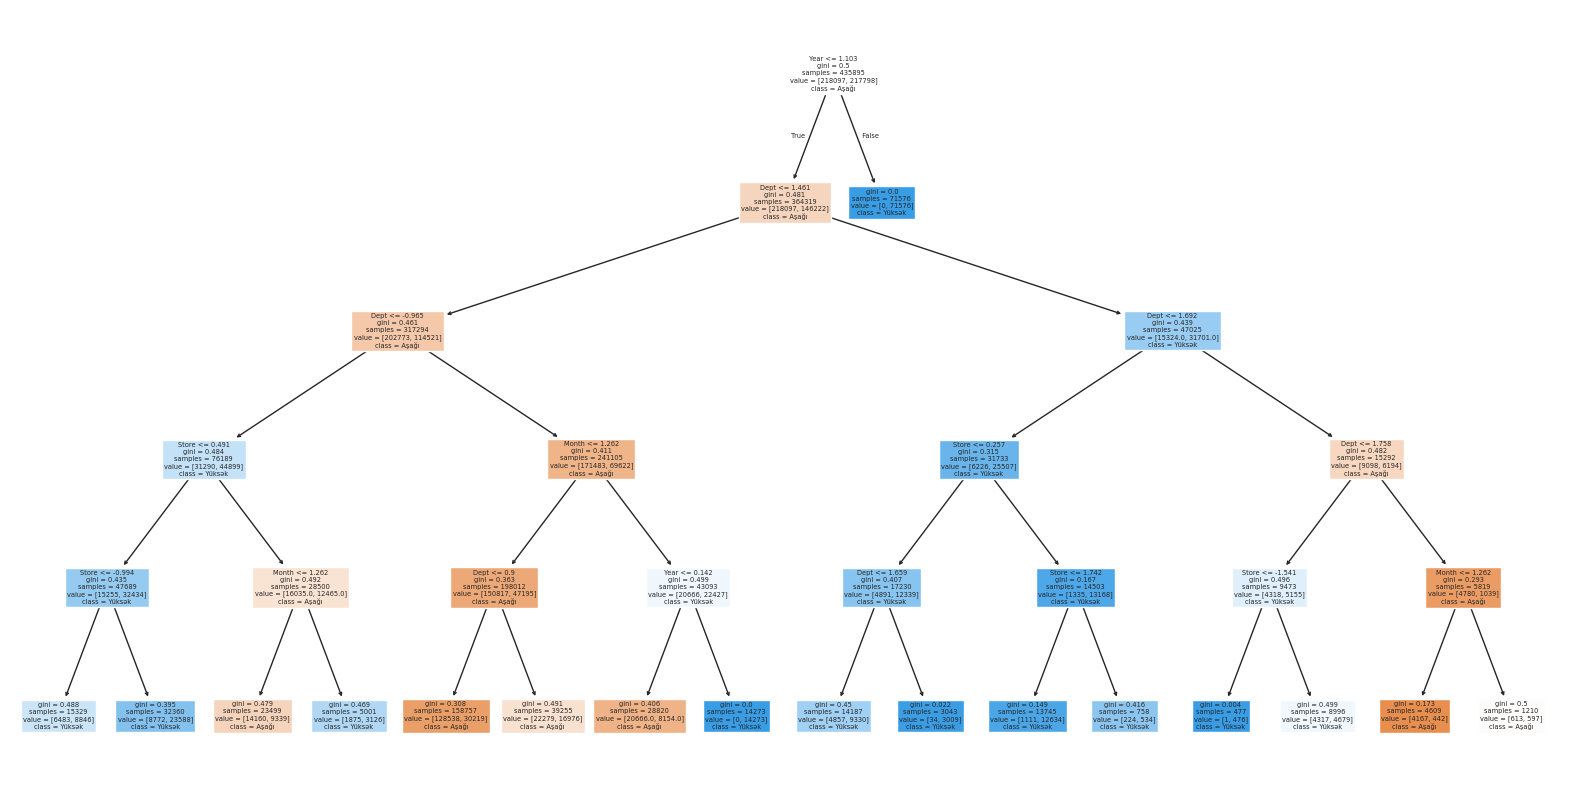

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(model, filled=True, feature_names=X.columns, class_names=['Aşağı', 'Yüksək'])
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96     54338
           1       0.97      0.96      0.96     54636

    accuracy                           0.96    108974
   macro avg       0.96      0.96      0.96    108974
weighted avg       0.96      0.96      0.96    108974



In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
from sklearn.ensemble import VotingClassifier
voting_clf = VotingClassifier(
    estimators=[('sgd_clf', sgd_clf),('log_reg', lr)],
    voting='hard'
)
voting_clf.fit(X_train,y_train)
voting_clf.score(X_test,y_test)

0.6472553086057224

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf=BaggingClassifier(DecisionTreeClassifier(),n_estimators=500,
                          max_samples=100,bootstrap=True,n_jobs=-1)
bag_clf.fit(X_train,y_train)
bag_clf.score(X_test,y_test)

0.8013471103198928

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
ada_clf=AdaBoostClassifier(DecisionTreeClassifier(max_depth=1),n_estimators=200,
                           learning_rate=0.5)
ada_clf.fit(X_train,y_train)
ada_clf.score(X_test,y_test)

0.7301099344797841

In [ ]:
from xgboost import XGBRegressor

xgb_reg=XGBRegressor(random_state=42)
xgb_reg.fit(X,y)
xgb_reg.score(X,y)

0.8363257646560669

In [ ]:
df

,Store,Dept,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Weekday,Month,Year,High_Sales
0,1,1.000000,24924.500000,0,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,0,130287.6,4,2,2010,1
1,1,1.000000,46039.490000,1,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,0,130287.6,4,2,2010,1
2,1,1.000000,41595.550000,0,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,0,130287.6,4,2,2010,1
3,1,1.000000,19403.540000,0,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,0,130287.6,4,2,2010,1
4,1,1.000000,21827.900000,0,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,0,130287.6,4,3,2010,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40,41,44.277301,15981.258123,0,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,0,196321.0,4,12,2011,1
41,42,44.277301,15981.258123,0,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,2,39690.0,4,12,2011,1
42,43,44.277301,15981.258123,0,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,2,41062.0,4,12,2011,1
43,44,44.277301,15981.258123,0,59.356198,3.405992,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,172.460809,7.826821,2,39910.0,4,12,2011,1


In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [ ]:
# from sklearn.metrics import classification_report

# print(classification_report(y_test, y_pred))

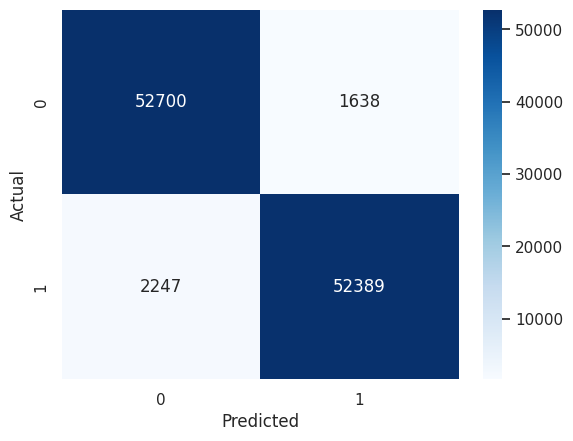

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[52700  1638]
 [ 2247 52389]]


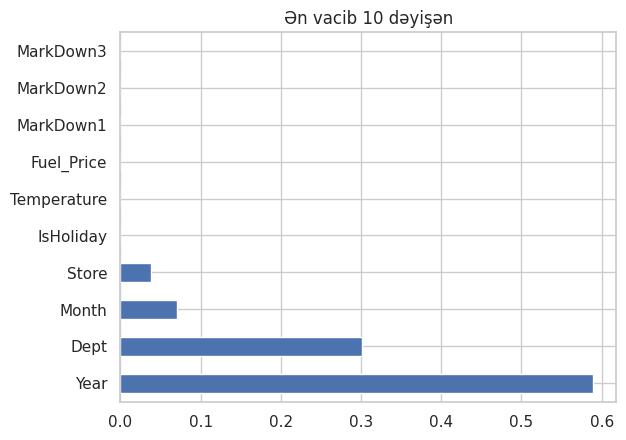

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feat_importance = pd.Series(model.feature_importances_, index=X.columns)
feat_importance.nlargest(10).plot(kind='barh')
plt.title("Ən vacib 10 dəyişən")
plt.show()

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(scale_pos_weight=3, random_state=42)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Əvvəlcə ölçekləmə
scaler = StandardScaler()

X_scaled_train = scaler.fit_transform(X_train)
X_scaled_test = scaler.transform(X_test)

# Polynomial feature-ləri yarat
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_train = poly.fit_transform(X_scaled_train)
X_poly_test = poly.transform(X_scaled_test)


In [ ]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_poly_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
y_pred = model.predict(X_poly_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.72      0.81      0.76     54338
           1       0.78      0.69      0.73     54636

    accuracy                           0.75    108974
   macro avg       0.75      0.75      0.75    108974
weighted avg       0.75      0.75      0.75    108974



In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
# X_poly = poly.fit_transform(X_scaled)
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_poly_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler
scaler=MinMaxScaler()
scaler.fit_transform(X)

array([[0.        , 0.        , 0.        , ..., 0.        , 0.09090909,
        0.        ],
       [0.        , 0.        , 1.        , ..., 0.        , 0.09090909,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.09090909,
        0.        ],
       ...,
       [0.95454545, 0.44160511, 0.        , ..., 0.        , 1.        ,
        0.33333333],
       [0.97727273, 0.44160511, 0.        , ..., 0.        , 1.        ,
        0.33333333],
       [1.        , 0.44160511, 0.        , ..., 0.        , 1.        ,
        0.33333333]])

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
model.score(X_test,y_test)

0.8911483473122029

In [ ]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(force_row_wise=True,max_bin=255,verbosity=-1,random_state=42)
lgbm_model.fit(X_train, y_train)

LGBMClassifier(force_row_wise=True, max_bin=255, random_state=42, verbosity=-1)

In [ ]:
lgbm_model.score(X_test,y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.949997247049755